# Detección de Anomalías Supervisada y No Supervisada - Dataset HIGGS

## Objetivo del Proyecto
Desarrollar una solución analítica para identificar y priorizar eventos anómalos (señales de colisión del Bosón de Higgs) en un dataset altamente desbalanceado (~1% de positividad). Se evaluarán enfoques supervisados, no supervisados e integrados para optimizar la generación de alertas y minimizar falsos positivos.


### 0. Carga de Datos

In [4]:
import pandas as pd
import numpy as np

parte1_path = "../data/higgs_anomaly_400k_part1.parquet"
parte2_path = "../data/higgs_anomaly_400k_part2.parquet"

df_parte1 = pd.read_parquet(parte1_path)

df_parte2 = pd.read_parquet(parte2_path)

df = pd.concat([df_parte1, df_parte2], ignore_index=True)

print(f"Dimensiones totales del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.")


Dimensiones totales del dataset: 400000 filas y 30 columnas.


## 1. Definición de Anomalía y Análisis de los Datos

In [6]:
df.head()

,event_id,lepton_pt,lepton_eta,lepton_phi,missing_energy_magnitude,missing_energy_phi,jet_1_pt,jet_1_eta,jet_1_phi,jet_1_b_tag,...,jet_4_phi,jet_4_b_tag,mass_jj,mass_jjj,mass_lv,mass_jlv,mass_bb,mass_wbb,mass_wwbb,is_signal
0,10564442,1.721567,0.372976,1.026355,0.177679,-1.078458,0.664977,-0.444639,-1.397525,2.173076,...,0.491491,0.0,1.038409,0.982106,0.989194,0.893509,1.281010,0.911054,0.860807,0
1,1420512,0.760769,1.657641,-1.018969,1.047911,1.413517,0.861657,1.148641,-0.510521,0.000000,...,1.141293,0.0,0.924844,0.919754,1.005618,0.807988,0.602472,0.945887,0.895652,0
2,10822309,0.572269,1.124880,-1.610451,1.245221,1.019396,0.773165,0.983273,-1.057693,2.173076,...,-0.356518,0.0,1.045784,1.012153,0.981957,0.626796,0.923795,0.709845,0.698548,0
3,6798554,0.734232,-0.933116,-0.273788,1.704093,1.650188,0.802662,0.029681,1.700984,1.086538,...,0.954287,0.0,0.986455,0.892395,1.529028,1.194787,1.427437,1.001249,0.841272,0
4,8415745,1.894144,-0.290297,0.158552,0.443843,-1.659044,1.868421,0.428744,1.673266,2.173076,...,0.414358,0.0,0.693345,0.666994,1.267468,1.673905,1.811831,1.272984,1.084105,0


### 1.1 Anomalía

El dataset HIGGS proviene de simulaciones de colisiones de partículas de alta energía en el Gran Colisionador de Hadrones (LHC). En estos experimentos, billones de protones chocan a velocidades cercanas a la de la luz para recrear condiciones extremas del universo. 

El objetivo principal es detectar el **Bosón de Higgs**, una partícula elemental que valida el Modelo Estándar de la física pero que tiene un tiempo de vida demasiado corto antes de desintegrarse en otras partículas (como leptones y jets). El reto radica en que los detectores registran una cantidad colosal de eventos ordinarios producto de interacciones físicas comunes y conocidas. Por lo tanto, el descubrimiento de la partícula de interés equivale a buscar una aguja en un pajar de dimensiones astronómicas.

---

#### Definición Formal de la Anomalía en el Dataset
Dentro del marco analítico de este caso de estudio, se establece que **la Anomalía es el evento de Señal (`is_signal = 1`)**, el cual representa la producción y desintegración del Bosón de Higgs. Por el contrario, los eventos de **Background (`is_signal = 0`)** representan el ruido de fondo ordinario. 

Para abordar metodológicamente este problema, separamos su significado en dos dimensiones técnicas:

#### 1.1.1 Definición Operativa
En la física de partículas experimental, las colisiones que generan partículas de interés son fenómenos sumamente raros y difíciles de replicar. La inmensa mayoría de los eventos registrados corresponden a procesos físicos comunes y ya conocidos, agrupados bajo la etiqueta de Background. Al ser la señal el fenómeno de interés científico pero críticamente escaso, el problema se modela bajo el paradigma operativo de detección de anomalías.

#### 1.1.2. Definición Metodológica y Formulación de la Hipótesis
Desde el punto de vista analítico, evaluaremos la anomalía bajo dos enfoques algorítmicos opuestos:

1. **Enfoque Supervisado (Anomalía por Desbalance Extremo):** La anomalía se aborda puramente por su baja frecuencia (~1.00% de probabilidad de ocurrencia). El reto matemático consiste en mitigar el sesgo del clasificador hacia la clase mayoritaria (Background), forzando al algoritmo a identificar patrones multidimensionales sutiles en los datos a pesar de la escasez de ejemplos.
2. **Enfoque No Supervisado (La Anomalía como Outlier de Densidad):** Bajo este marco teórico, una anomalía se define tradicionalmente como un vector cuyas propiedades numéricas se desvían de la distribución central o habitan en regiones de baja densidad estadística. 

> **Hipótesis Central del Proyecto:** *"Que un evento sea operativamente poco frecuente (Señal) no implica que sea estadísticamente atípico (Outlier)."* 
>
> A través del Análisis Exploratorio de Datos (EDA) desafiaremos esta definición tradicional. Evaluaremos si el Bosón de Higgs realmente habita en las colas aisladas de la distribución (lo que permitiría a modelos no supervisados como `Isolation Forest` aislarlo de forma natural) o si, por el contrario, comparte exactamente el mismo espacio geométrico y rango que el ruido de fondo, diferenciándose únicamente en su nivel de concentración. Esta validación geométrica evalua la superioridad de un enfoque sobre el otro.

---

#### Justificación
Clasificar la señal como una "anomalía" se justifica bajo estos criterios:

* **Justificación por Escasez Operativa:** Los datos confirman que de cada 100,000 eventos, únicamente 1,000 corresponden a la señal (~1.00%). Al estar confinada a esta probabilidad analítica, cumple con la condición de escasez severa requerida para el diseño de sistemas de alerta.
* **Justificación Algorítmica (Asimetría del Error):** Si el modelo confunde el ruido con una señal (Falso Positivo), genera una alerta analizable. Pero si el modelo clasifica una señal como ruido (Falsos Negativo), el Bosón de Higgs se "borra" y se pierde el hito científico. Al requerir que el sistema penalice severamente la pérdida de eventos escasos, el problema se aleja de la clasificación tradicional y se convierte en un diseño de detección y priorización de anomalías.


### 1.2 Análisis de la Variable Objetivo y Cuantificación del Desbalance

En esta sección analizamos cuantitativamente la columna `is_signal` para medir el grado de desbalance entre los eventos de Background (0) y Señal (1).

El grado de desbalance determina la estrategia de evaluación del modelo. Si el desbalance es extremo (por ejemplo, menor al 5% para la clase minoritaria), las métricas tradicionales como la precisión global (*Accuracy*) quedan totalmente invalidadas. Este análisis nos dará la base para decidir si requerimos técnicas de remuestreo y guiará la elección de métricas robustas (*Precision-Recall AUC*).


--- CUANTIFICACION DEL DESBALANCE ---
Clase 0 (Background): 396,000 eventos (99.00%)
Clase 1 (Señal):     4,000 eventos (1.00%)
Total de registros:  400,000



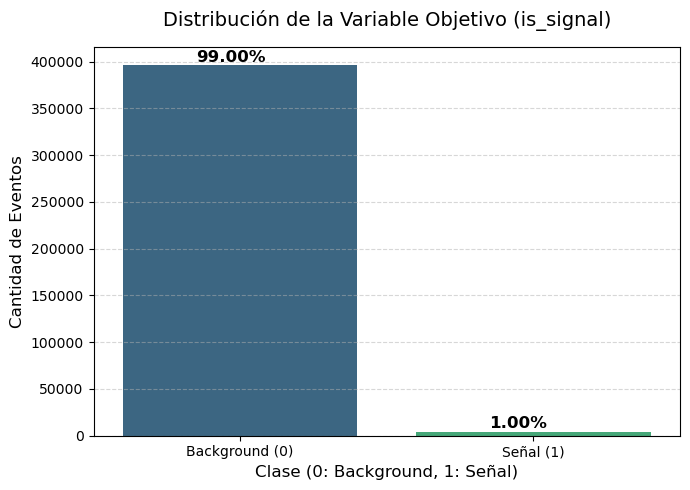

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

conteos = df['is_signal'].value_counts()

porcentajes = df['is_signal'].value_counts(normalize=True) * 100

print("--- CUANTIFICACION DEL DESBALANCE ---")
print(f"Clase 0 (Background): {conteos[0]:,} eventos ({porcentajes[0]:.2f}%)")
print(f"Clase 1 (Señal):     {conteos[1]:,} eventos ({porcentajes[1]:.2f}%)")
print(f"Total de registros:  {df.shape[0]:,}\n")

plt.figure(figsize=(7, 5))
ax = sns.countplot(x='is_signal', data=df, palette='viridis', hue='is_signal', legend=False)

for p in ax.patches:
    percentage = '{:.2f}%'.format(100 * p.get_height() / len(df))
    x = p.get_x() + p.get_width() / 2 - 0.15
    y = p.get_height() + (len(df) * 0.01)
    ax.annotate(percentage, (x, y), fontsize=12, fontweight='bold')

plt.title('Distribución de la Variable Objetivo (is_signal)', fontsize=14, pad=15)
plt.xlabel('Clase (0: Background, 1: Señal)', fontsize=12)
plt.ylabel('Cantidad de Eventos', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Background (0)', 'Señal (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Segmentación de Características: Bajo Nivel vs. Alto Nivel

Para diseñar una estrategia analítica efectiva, dividimos las variables predictoras (excluyendo `event_id` e `is_signal`) en dos categorías fundamentales según su procedencia física y matemática.

### Variables de Bajo Nivel
Corresponden a las propiedades física puras medidas directamente por los detectores del colisionador de partículas inmediatamente después del choque. Incluyen:
* **Momentos transversales (`_pt`)**: La energía/movimiento de las partículas en el eje perpendicular a la colisión.
* **Pseudorapidez (`_eta`)** y **Ángulos Azimutales (`_phi`)**: Coordenadas espaciales que identifican la trayectoria exacta de salida de los leptones y jets.
* **Magnitudes de energía faltante (`missing_energy_magnitude`)**: Energía que teóricamente debió registrarse pero "desapareció" (lo que sugiere la presencia de partículas invisibles como neutrinos o materia oscura).

### Variables de Alto Nivel
Son funciones no lineales complejas calculadas posteriormente por los físicos mediante ecuaciones teóricas (como variables de masa invariante: `mass_jj`, `mass_mmbb`, etc.). 

In [13]:
# Verificación de los nombres de las variables
# Imprimir las columnas desde la posición 20 hasta la 30 para ver la frontera real
for i, col in enumerate(df.columns):
    if i >= 20:
        print(f"Índice {i}: {col}")


Índice 20: jet_4_phi
Índice 21: jet_4_b_tag
Índice 22: mass_jj
Índice 23: mass_jjj
Índice 24: mass_lv
Índice 25: mass_jlv
Índice 26: mass_bb
Índice 27: mass_wbb
Índice 28: mass_wwbb
Índice 29: is_signal


In [12]:
columnas_totales = df.columns.tolist()

identificadores = ['event_id']
objetivo = ['is_signal']

features_bajo_nivel = columnas_totales[1:22]

features_alto_nivel = columnas_totales[22:29]

print(f"Variables de Bajo Nivel detectadas: {len(features_bajo_nivel)}")
print(f"Variables de Alto Nivel detectadas: {len(features_alto_nivel)}")
print(f"Otras Variables:       {len(identificadores) + len(objetivo)}")
print(f"Suma total:              {len(features_bajo_nivel) + len(features_alto_nivel) + len(identificadores) + len(objetivo)}")

print("\n Bajo Nivel:", features_bajo_nivel)
print("Alto Nivel:", features_alto_nivel)


Variables de Bajo Nivel detectadas: 21
Variables de Alto Nivel detectadas: 7
Otras Variables:       2
Suma total:              30

 Bajo Nivel: ['lepton_pt', 'lepton_eta', 'lepton_phi', 'missing_energy_magnitude', 'missing_energy_phi', 'jet_1_pt', 'jet_1_eta', 'jet_1_phi', 'jet_1_b_tag', 'jet_2_pt', 'jet_2_eta', 'jet_2_phi', 'jet_2_b_tag', 'jet_3_pt', 'jet_3_eta', 'jet_3_phi', 'jet_3_b_tag', 'jet_4_pt', 'jet_4_eta', 'jet_4_phi', 'jet_4_b_tag']
Alto Nivel: ['mass_jj', 'mass_jjj', 'mass_lv', 'mass_jlv', 'mass_bb', 'mass_wbb', 'mass_wwbb']


### 1.3 Señal vs. Background

En esta sección realizamos un análisis estadístico y visual comparativo para identificar si las variables predictoras muestran comportamientos marcadamente distintos cuando el evento es una Señal (1) frente a cuando es Background (0).

Si las medias y las distribuciones de ambos grupos son idénticas, los modelos tendrán serias dificultades para separarlos. Si encontramos variables donde las curvas de densidad no se solapan, habremos descubierto los "puntos clave" que los algoritmos utilizarán para identificar el Bosón de Higgs. Además, esto nos permitirá comprobar si la señal se comporta como un outlier tradicional o no.


In [14]:
df_sin_id = df.drop(columns=['event_id'])
medias_por_clase = df_sin_id.groupby('is_signal').mean().T

medias_por_clase.columns = ['Media_Background_0', 'Media_Señal_1']

medias_por_clase['Diferencia_Absoluta'] = (medias_por_clase['Media_Señal_1'] - medias_por_clase['Media_Background_0']).abs()
medias_por_clase['Cambio_Porcentual (%)'] = (medias_por_clase['Diferencia_Absoluta'] / medias_por_clase['Media_Background_0']) * 100

print("--- VARIABLES CON MAYOR DIFERENCIA DE MEDIAS ---")
medias_por_clase.sort_values(by='Cambio_Porcentual (%)', ascending=False).head(10)


--- VARIABLES CON MAYOR DIFERENCIA DE MEDIAS ---


,Media_Background_0,Media_Señal_1,Diferencia_Absoluta,Cambio_Porcentual (%)
lepton_eta,0.000030,-0.024659,0.024689,82872.171875
jet_3_phi,0.001032,-0.038597,0.039629,3841.093018
jet_2_phi,0.000579,-0.011272,0.011851,2048.159668
jet_4_phi,0.000726,0.002466,0.001740,239.599014
mass_bb,1.057213,0.899446,0.157767,14.922937
jet_2_b_tag,1.052867,0.928585,0.124282,11.804118
missing_energy_magnitude,1.061835,0.942872,0.118963,11.203506
mass_wwbb,1.000019,0.918667,0.081352,8.135055
jet_4_b_tag,0.979147,1.039932,0.060786,6.208048
lepton_pt,1.020650,0.957650,0.063000,6.172535


Al analizar el cambio porcentual, observamos un fenómeno matemático engañoso en variables como `lepton_eta` (82,872%) y `jet_3_phi` (3,841%). 

En física de partículas, los ángulos de salida (`eta` y `phi`) se distribuyen simétricamente alrededor de cero. Por lo tanto, el promedio real de estas variables tanto para la Señal como para el Background es prácticamente **cero** (por ejemplo, `lepton_eta` en Background es `0.000030`). Al calcular un cambio porcentual dividiendo entre un número tan cercano a cero, cualquier pequeña variación matemática (como `-0.024`) genera un porcentaje astronómico. Físicamente, esto no significa que la señal sea drásticamente diferente, sino que ambas clases están centradas en el origen.


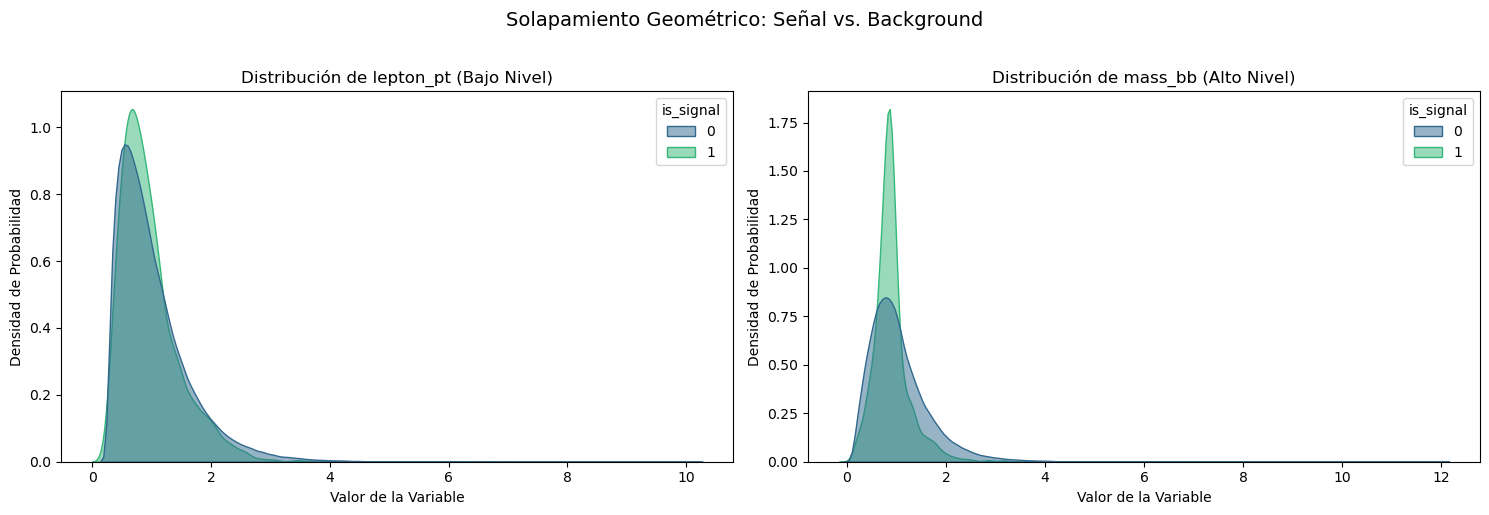

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.kdeplot(data=df, x='lepton_pt', hue='is_signal', fill=True, common_norm=False, palette='viridis', alpha=0.5, ax=axes[0])
axes[0].set_title('Distribución de lepton_pt (Bajo Nivel)', fontsize=12)
axes[0].set_xlabel('Valor de la Variable')
axes[0].set_ylabel('Densidad de Probabilidad')

sns.kdeplot(data=df, x='mass_bb', hue='is_signal', fill=True, common_norm=False, palette='viridis', alpha=0.5, ax=axes[1])
axes[1].set_title('Distribución de mass_bb (Alto Nivel)', fontsize=12)
axes[1].set_xlabel('Valor de la Variable')
axes[1].set_ylabel('Densidad de Probabilidad')

plt.suptitle('Solapamiento Geométrico: Señal vs. Background', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Comportamiento Geométrico de las Distribuciones (Análisis del Solapamiento)**

En la separación se observa en variables físicas de masa y energía:

1. **Bajo Nivel (`lepton_pt`):** Las curvas de densidad para Señal (1) y Background (0) son muy idénticas y están completamente solapadas. Esto demuestra empíricamente que **la Señal NO es un outlier estadístico**; un leptón proveniente del Bosón de Higgs se mueve con impulsos idénticos a los del ruido común.

2. **Alto Nivel (`mass_bb`):** A diferencia de lo que se podría esperar, no existe un desplazamiento horizontal en las distribuciones; ambas clases están centradas en el mismo rango de valores. La única diferencia radica en la **amplitud de la densidad (eje Y)**: el Señal (1) presenta un pico de concentración significativamente más alto y agudo, mientras que la Background (0) mantiene una base y forma idénticas pero con un pico de densidad menor. 

Dado que las distribuciones comparten exactamente el mismo espacio geométrico (mismos centros y colas) y solo difieren en su nivel de concentración, confirmamos que **la Señal se esconde de forma idéntica dentro del ruido**. 

Esto tiene una implicación para el caso de estudio: los algoritmos **No Supervisados** (como *Isolation Forest*), que dependen de encontrar puntos en regiones aisladas o de baja densidad del espacio, van a fracasar casi por completo, ya que la señal esta exactamente en la misma región de alta densidad que el background. Por lo tanto, el enfoque **Supervisado** es ayudará mejor para intentar encontrar patrones o interacciones sutiles entre múltiples variables simultáneamente que permitan romper este solapamiento.

### 1.4 Comparación Bajo Nivel vs. Alto Nivel vs. Conjunto Completo

En esta sección realizamos un Análisis Exploratorio de Datos (EDA) comparativo entre los tres conjuntos de características definidos para el caso de estudio. 

Cada bloque de variables aporta una estructura geométrica distinta al espacio de datos. Comparar sus correlaciones, su dispersión y su nivel de solapamiento matemático nos permitirá diagnosticar, antes de entrenar cualquier modelo, qué tan complejo será el límite de decisión y si la ingeniería de características experta (alto nivel) realmente simplifica la tarea de clasificación frente a los datos de bajo nivel.


#### Análisis de Correlación Promedio


In [22]:
def obtener_correlacion_promedio(df_sub):
    corr = df_sub.corr().abs()
    mask = np.eye(corr.shape[0], dtype=bool)
    return corr.values[~mask].mean()

corr_bajo = obtener_correlacion_promedio(df[features_bajo_nivel])
corr_alto = obtener_correlacion_promedio(df[features_alto_nivel])
corr_completo = obtener_correlacion_promedio(df[features_bajo_nivel + features_alto_nivel])

print(f"Correlación absoluta promedio en Bajo Nivel: {corr_bajo:.4f}")
print(f"Correlación absoluta promedio en Alto Nivel: {corr_alto:.4f}")
print(f"Correlación absoluta promedio en Conjunto Completo: {corr_completo:.4f}\n")


Correlación absoluta promedio en Bajo Nivel: 0.0448
Correlación absoluta promedio en Alto Nivel: 0.3236
Correlación absoluta promedio en Conjunto Completo: 0.0718



El contraste cuantitativo de la correlación absoluta promedio entre los tres bloques de variables nos muestra la naturaleza estructural del dataset:

* **Bajo Nivel (0.0448):** Confirma una independencia casi estadística entre las mediciones físicas en bruto. Esto refleja la naturaleza del detector, donde variables cinemáticas y espaciales independientes (momentos, ángulos) no se condicionan linealmente entre sí. Metodológicamente, esto implica que el patrón de la Señal está disperso en interacciones multivariadas complejas que requieren algoritmos no lineales para ser extraídas.
* **Alto Nivel (0.3236):** Exhibe una conectividad significativamente superior debido a la redundancia matemática. Al ser masas invariantes calculadas mediante la combinación de las variables de bajo nivel, comparten componentes físicos comunes en sus ecuaciones, lo que eleva su correlación. Esto demuestra que el bloque de alto nivel actúa como un espacio de información pre-sintetizada y guiada por el conocimiento del dominio.
* **Conjunto Completo (0.0718):** El promedio global se diluye debido a la dominancia numérica de las 21 variables de bajo nivel sobre las 7 de alto nivel. 

Los modelos basados en árboles de decisión se beneficiarán enormemente de la coexistencia de ambos: utilizarán las variables de alto nivel como "atajos predictivos" gracias a su síntesis matemática, mientras usan las de bajo nivel para afinar la frontera de decisión con los datos puros en bruto.


#### Poder De Separación (MEDIANAS DE SCORE F)

In [ ]:
from sklearn.feature_selection import f_classif

f_scores_bajo, _ = f_classif(df[features_bajo_nivel], df['is_signal'])
f_scores_alto, _ = f_classif(df[features_alto_nivel], df['is_signal'])
f_scores_completo, _ = f_classif(df[features_bajo_nivel + features_alto_nivel], df['is_signal'])

print("--- PODER DE SEPARACIÓN DISCRIMINANTE (MEDIANAS DE SCORE F) ---")
print(f"Capacidad de separación mediana - Bajo Nivel: {np.median(f_scores_bajo):.2f}")
print(f"Capacidad de separación mediana - Alto Nivel: {np.median(f_scores_alto):.2f}")
print(f"Capacidad de separación mediana - Conjunto Completo: {np.median(f_scores_completo):.2f}")


Capacidad de separación mediana - Bajo Nivel: 2.31
Capacidad de separación mediana - Alto Nivel: 19.47
Capacidad de separación mediana - Conjunto Completo: 4.40


El análisis de la capacidad discriminante mediante las medianas del Score F revela el impacto de la ingeniería de características en el dataset:

* **Bajo Nivel (2.31):** Registra el valor más bajo. Confirma matemáticamente el solapamiento extremo observado en los gráficos de densidad. De forma individual, las mediciones de los detectores no tienen la fuerza estadística para separar la señal del ruido.
* **Alto Nivel (19.47):** Presenta un incremento en el poder de separación. Las masas calculadas mitigan el ruido y clarifican la frontera entre los grupos, facilitando la tarea de clasificación.
* **Conjunto Completo (4.40):** El poder discriminante mediano se diluye debido a la superioridad numérica de las variables de bajo nivel (21 columnas débiles frente a 7 fuertes).

**Implicación para el Caso de Estudio:** Este resultado predice que un modelo entrenado únicamente con variables de Alto Nivel podría ser sumamente eficiente y rápido. Sin embargo, para maximizar la detección en el Conjunto Completo, se requerirán modelos robustos basados en árboles capaces de seleccionar automáticamente las características con mayor Score F e ignorar las que añaden ruido matemático.


#### Gráfico de Dispersión 

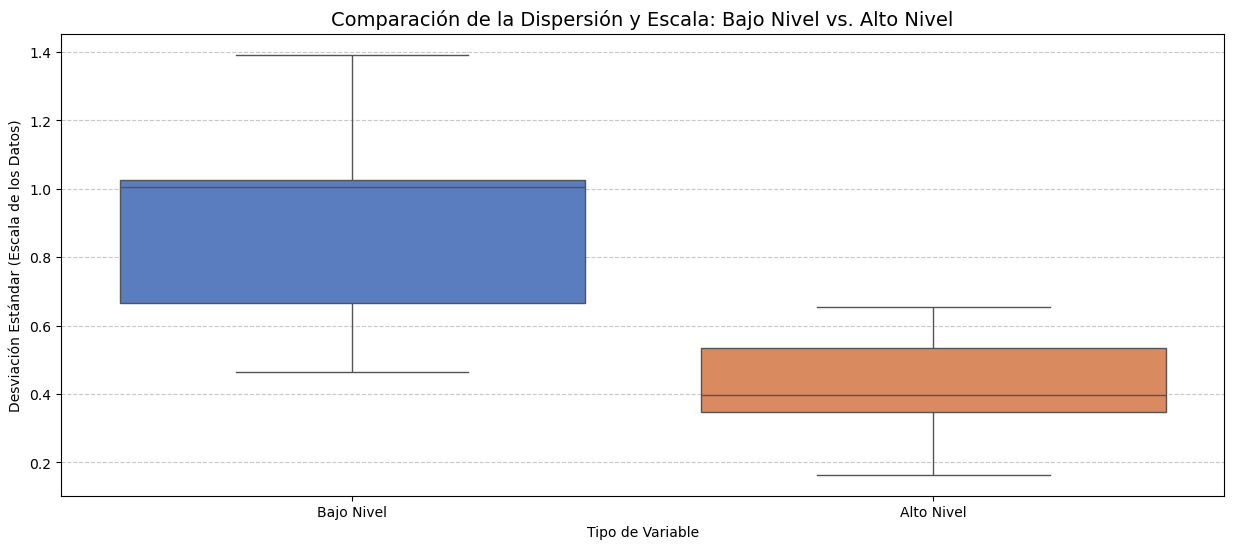

In [24]:
plt.figure(figsize=(15, 6))

desviaciones = pd.DataFrame({
    'Desviación Estándar': df[features_bajo_nivel + features_alto_nivel].std(),
    'Tipo de Variable': ['Bajo Nivel']*len(features_bajo_nivel) + ['Alto Nivel']*len(features_alto_nivel)
})

sns.boxplot(data=desviaciones, x='Tipo de Variable', y='Desviación Estándar', palette='muted', hue='Tipo de Variable', legend=False)
plt.title('Comparación de la Dispersión y Escala: Bajo Nivel vs. Alto Nivel', fontsize=14)
plt.ylabel('Desviación Estándar (Escala de los Datos)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


El análisis de las desviaciones estándar revela un comportamiento opuesto en la distribución de las escalas de ambos bloques:

* **Bajo Nivel:** Presenta una alta dispersión debido a la naturaleza caótica de las colisiones en bruto, donde la energía y los ángulos varían drásticamente en cada evento registrado por los detectores.
* **Alto Nivel:** Muestra una dispersión significativamente menor y compacta. Esto ocurre porque las fórmulas matemáticas calculan masas de partículas específicas; por leyes físicas, estas masas tienden a concentrarse en rangos fijos y controlados, reduciendo la variabilidad del ruido.

**Implicación Crítica para Modelos de Distancia:** Debido a que el bloque de bajo nivel tiene variables con el doble de dispersión y escala que el de alto nivel, el uso del **Conjunto Completo** en algoritmos sensibles a distancias se verá sesgado, dándole más peso visual al bajo nivel de forma artificial. Esto justifica la necesidad de aplicar una estandarización de datos (`StandardScaler`) antes de entrenar dichos modelos.
